## PVS Dataset — Exploratory Data Analysis
**Project:** Durability Analytics Platform  
**Dataset:** PVS 1 — Passive Vehicular Sensors (Kaggle)  
**Purpose:** Understand the raw data structure, validate sensor signals, 
and extract key durability insights before building the pipeline.

### Key Findings
- Suspension arm sees **3x more vibration energy** than dashboard (suspension isolation working)
- Cobblestone RMS = **3.25 m/s²** vs Asphalt = **0.033 m/s²** → ~100x difference in raw signal
- Full dataset RMS below suspension = **6.17 m/s²** (mixed road types)
- Peak impact = **66.17 m/s²** (~7g) — likely a severe pothole or curb strike
- **11 distinct speed bump events** detected across 3,455 samples
- 24 minutes of data at 100Hz across cobblestone (43%), asphalt (39%), dirt (18%)

In [1]:
import pandas as pd
import numpy as np
import os
os.chdir("D:/Durability Analytics")  # make sure we're in the right folder

labels = pd.read_csv("data/raw/dataset_labels.csv")
print("Shape:", labels.shape)
print("\nColumns:", labels.columns.tolist())
print("\nFirst 5 rows:")
labels.head()

Shape: (144036, 14)

Columns: ['paved_road', 'unpaved_road', 'dirt_road', 'cobblestone_road', 'asphalt_road', 'no_speed_bump', 'speed_bump_asphalt', 'speed_bump_cobblestone', 'good_road_left', 'regular_road_left', 'bad_road_left', 'good_road_right', 'regular_road_right', 'bad_road_right']

First 5 rows:


,paved_road,unpaved_road,dirt_road,cobblestone_road,asphalt_road,no_speed_bump,speed_bump_asphalt,speed_bump_cobblestone,good_road_left,regular_road_left,bad_road_left,good_road_right,regular_road_right,bad_road_right
0,1,0,0,0,1,1,0,0,1,0,0,1,0,0
1,1,0,0,0,1,1,0,0,1,0,0,1,0,0
2,1,0,0,0,1,1,0,0,1,0,0,1,0,0
3,1,0,0,0,1,1,0,0,1,0,0,1,0,0
4,1,0,0,0,1,1,0,0,1,0,0,1,0,0


In [2]:
mpu_left = pd.read_csv("data/raw/dataset_gps_mpu_left.csv")
print("Shape:", mpu_left.shape)
print("\nColumns:", mpu_left.columns.tolist())
print("\nFirst 5 rows:")
mpu_left.head()

Shape: (144036, 32)

Columns: ['timestamp', 'acc_x_dashboard', 'acc_y_dashboard', 'acc_z_dashboard', 'acc_x_above_suspension', 'acc_y_above_suspension', 'acc_z_above_suspension', 'acc_x_below_suspension', 'acc_y_below_suspension', 'acc_z_below_suspension', 'gyro_x_dashboard', 'gyro_y_dashboard', 'gyro_z_dashboard', 'gyro_x_above_suspension', 'gyro_y_above_suspension', 'gyro_z_above_suspension', 'gyro_x_below_suspension', 'gyro_y_below_suspension', 'gyro_z_below_suspension', 'mag_x_dashboard', 'mag_y_dashboard', 'mag_z_dashboard', 'mag_x_above_suspension', 'mag_y_above_suspension', 'mag_z_above_suspension', 'temp_dashboard', 'temp_above_suspension', 'temp_below_suspension', 'timestamp_gps', 'latitude', 'longitude', 'speed']

First 5 rows:


,timestamp,acc_x_dashboard,acc_y_dashboard,acc_z_dashboard,acc_x_above_suspension,acc_y_above_suspension,acc_z_above_suspension,acc_x_below_suspension,acc_y_below_suspension,acc_z_below_suspension,...,mag_x_above_suspension,mag_y_above_suspension,mag_z_above_suspension,temp_dashboard,temp_above_suspension,temp_below_suspension,timestamp_gps,latitude,longitude,speed
0,1.577219e+09,0.365116,0.167893,9.793961,0.327626,0.172733,9.781861,0.024797,0.172611,9.793824,...,75.340967,-7.537556,-0.334800,35.065355,33.340132,31.782640,1.577219e+09,-27.717841,-51.098865,0.009128
1,1.577219e+09,0.392649,0.176273,9.771216,0.381496,0.189492,9.699261,0.024797,0.194158,9.842905,...,75.300243,-6.469241,-5.222873,34.993471,33.172402,31.782640,1.577219e+09,-27.717841,-51.098865,0.009128
2,1.577219e+09,0.409408,0.181062,9.732909,0.283333,0.182310,9.807000,0.003249,0.227677,9.888395,...,75.463140,-7.893661,-4.687194,34.993471,33.412017,31.926408,1.577219e+09,-27.717841,-51.098865,0.009128
3,1.577219e+09,0.371101,0.164302,9.749668,0.314458,0.230194,9.739963,0.005643,0.172611,9.871635,...,75.463140,-7.893661,-4.687194,34.969509,33.220325,31.926408,1.577219e+09,-27.717841,-51.098865,0.009128
4,1.577219e+09,0.390255,0.159514,9.869378,0.344385,0.202660,9.762708,0.005643,0.200144,9.860862,...,74.933726,-8.012363,-4.084555,34.945548,33.220325,31.830563,1.577219e+09,-27.717841,-51.098865,0.009128


In [3]:
print("=== MPU Left Stats ===")
print(mpu_left.describe())

=== MPU Left Stats ===
          timestamp  acc_x_dashboard  acc_y_dashboard  acc_z_dashboard  \
count  1.440360e+05    144036.000000    144036.000000    144036.000000   
mean   1.577220e+09        -0.171308         0.015106         9.719331   
std    4.157976e+02         1.399775         1.940585         1.831907   
min    1.577219e+09       -10.735600       -13.446734        -6.418376   
25%    1.577219e+09        -0.912191        -0.829292         8.904515   
50%    1.577220e+09        -0.102951         0.090082         9.754456   
75%    1.577220e+09         0.543484         0.839467        10.522995   
max    1.577220e+09         9.033323        14.258967        24.665544   

       acc_x_above_suspension  acc_y_above_suspension  acc_z_above_suspension  \
count           144036.000000           144036.000000           144036.000000   
mean                -0.101238                0.025862                9.802781   
std                  1.290272                1.465464              

In [4]:
# Decode one-hot back to readable labels
road_type = labels[['asphalt_road','cobblestone_road','dirt_road','unpaved_road']].idxmax(axis=1).str.replace('_road','')
road_quality = labels[['good_road_left','regular_road_left','bad_road_left']].idxmax(axis=1).str.replace('_road_left','')
speed_bump = (labels['speed_bump_asphalt'] | labels['speed_bump_cobblestone']).astype(int)

print("Road type distribution:")
print(road_type.value_counts())
print("\nRoad quality distribution:")
print(road_quality.value_counts())
print("\nSpeed bump events:", speed_bump.sum())

Road type distribution:
cobblestone    61659
asphalt        56509
dirt           25868
Name: count, dtype: int64

Road quality distribution:
regular    65304
good       56577
bad        22155
Name: count, dtype: int64

Speed bump events: 3455


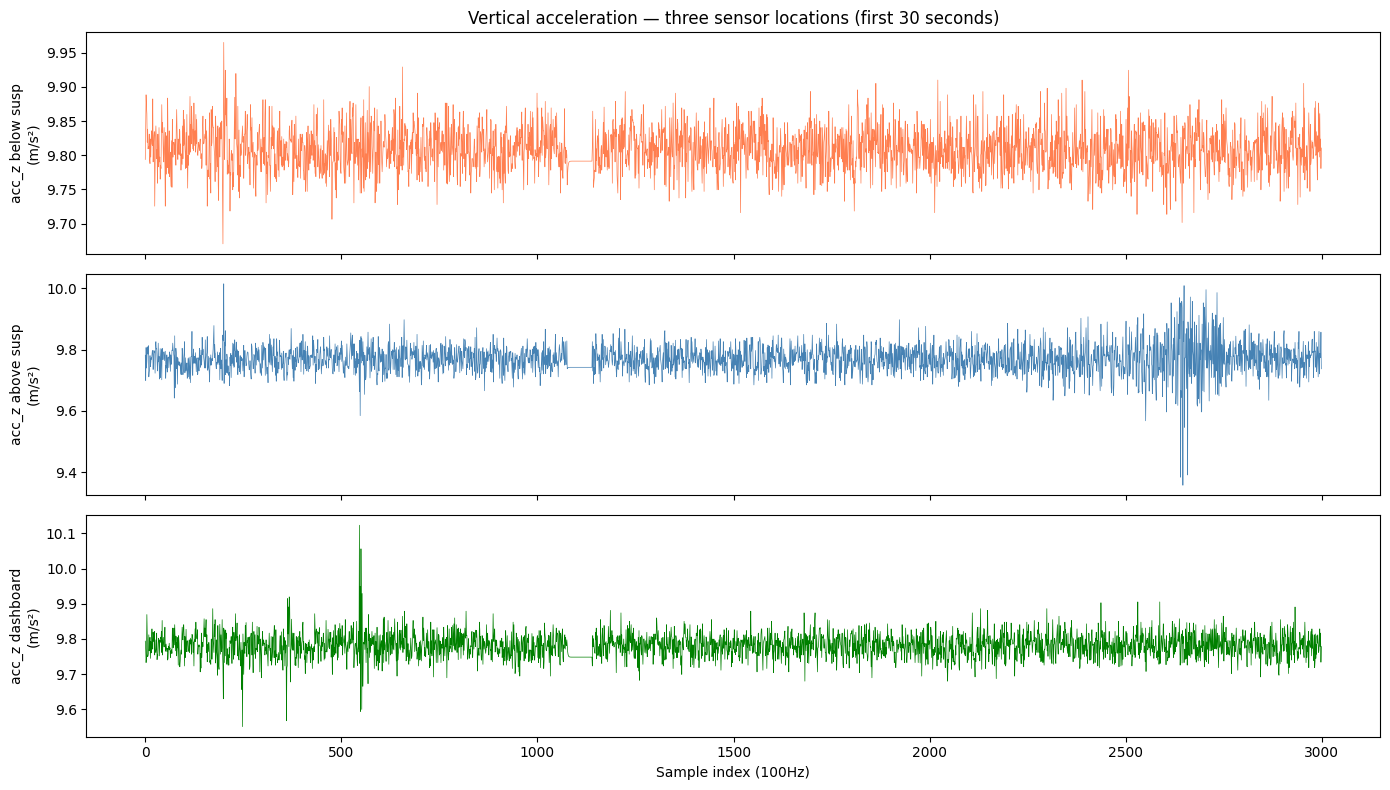

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(mpu_left['acc_z_below_suspension'].values[:3000], linewidth=0.5, color='coral')
axes[0].set_ylabel('acc_z below susp\n(m/s²)')
axes[0].set_title('Vertical acceleration — three sensor locations (first 30 seconds)')

axes[1].plot(mpu_left['acc_z_above_suspension'].values[:3000], linewidth=0.5, color='steelblue')
axes[1].set_ylabel('acc_z above susp\n(m/s²)')

axes[2].plot(mpu_left['acc_z_dashboard'].values[:3000], linewidth=0.5, color='green')
axes[2].set_ylabel('acc_z dashboard\n(m/s²)')
axes[2].set_xlabel('Sample index (100Hz)')

plt.tight_layout()
plt.show()

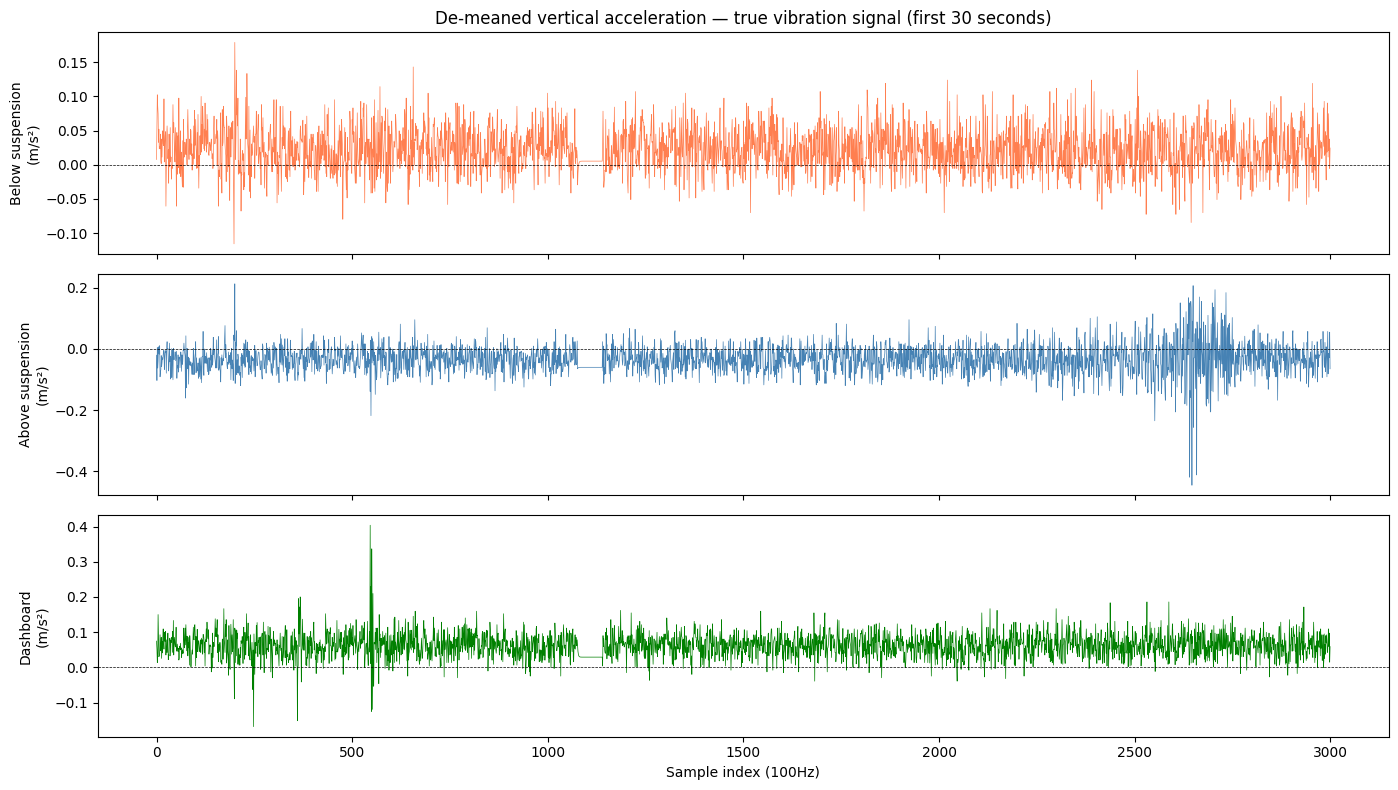

RMS vibration energy per location:
  Below suspension : 6.1655 m/s²
  Above suspension : 2.0792 m/s²
  Dashboard        : 1.8319 m/s²


In [6]:
# Remove gravity (de-mean each signal) and re-plot
# This reveals the true vibration signal

mpu_left['acc_z_below_susp_demean'] = mpu_left['acc_z_below_suspension'] - mpu_left['acc_z_below_suspension'].mean()
mpu_left['acc_z_above_susp_demean'] = mpu_left['acc_z_above_suspension'] - mpu_left['acc_z_above_suspension'].mean()
mpu_left['acc_z_dash_demean']       = mpu_left['acc_z_dashboard']        - mpu_left['acc_z_dashboard'].mean()

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(mpu_left['acc_z_below_susp_demean'].values[:3000], linewidth=0.5, color='coral')
axes[0].set_ylabel('Below suspension\n(m/s²)')
axes[0].set_title('De-meaned vertical acceleration — true vibration signal (first 30 seconds)')
axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--')

axes[1].plot(mpu_left['acc_z_above_susp_demean'].values[:3000], linewidth=0.5, color='steelblue')
axes[1].set_ylabel('Above suspension\n(m/s²)')
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')

axes[2].plot(mpu_left['acc_z_dash_demean'].values[:3000], linewidth=0.5, color='green')
axes[2].set_ylabel('Dashboard\n(m/s²)')
axes[2].set_xlabel('Sample index (100Hz)')
axes[2].axhline(0, color='black', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.show()

# Print RMS of each (measure of vibration energy)
print("RMS vibration energy per location:")
print(f"  Below suspension : {mpu_left['acc_z_below_susp_demean'].std():.4f} m/s²")
print(f"  Above suspension : {mpu_left['acc_z_above_susp_demean'].std():.4f} m/s²")
print(f"  Dashboard        : {mpu_left['acc_z_dash_demean'].std():.4f} m/s²")

RMS vibration by road type (below suspension):
  asphalt         RMS = 3.2122 m/s²   (56,509 samples)
  cobblestone     RMS = 7.2715 m/s²   (61,659 samples)
  dirt            RMS = 7.9431 m/s²   (25,868 samples)

RMS vibration by road quality:
  good            RMS = 3.1729 m/s²
  regular         RMS = 7.6805 m/s²
  bad             RMS = 6.8952 m/s²


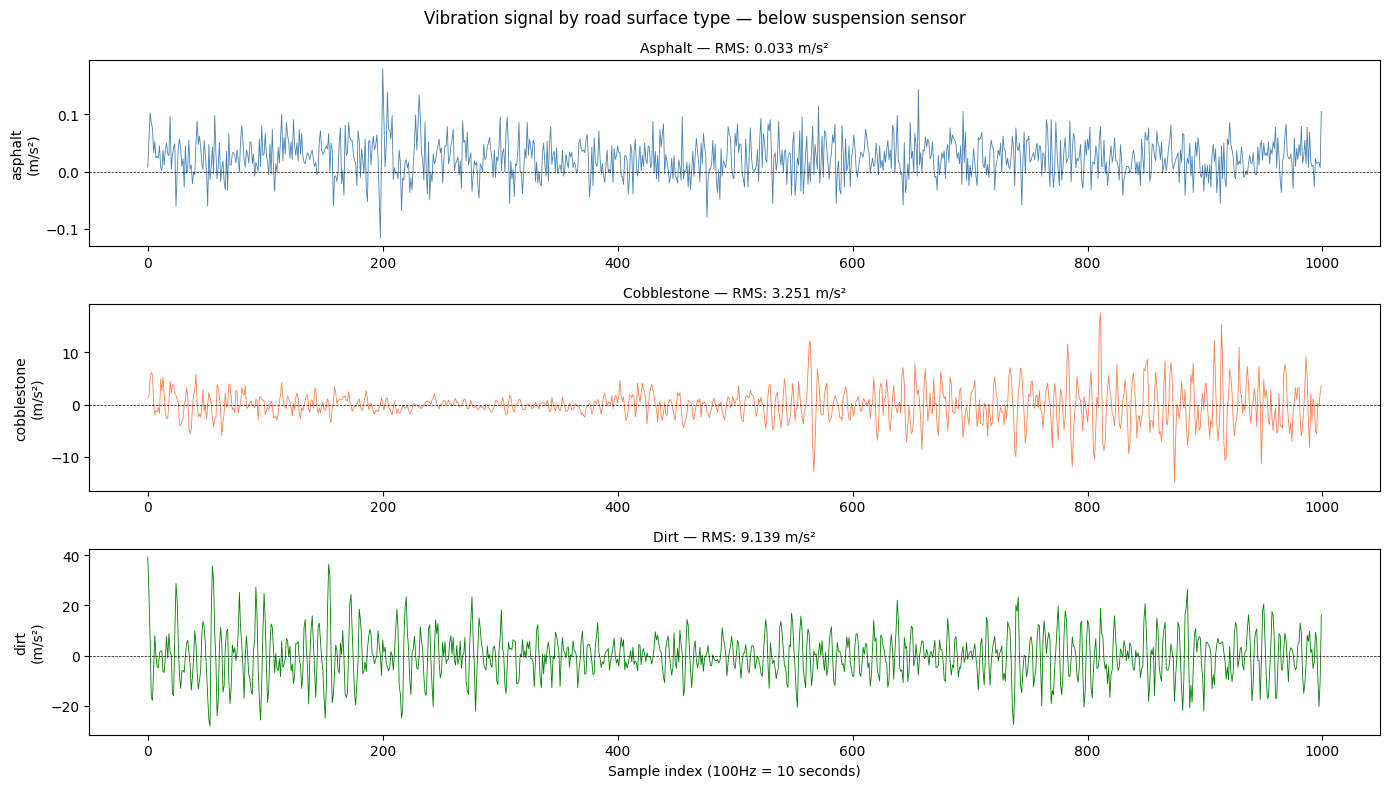

In [8]:
# Merge labels with mpu data by index
mpu_left['road_type'] = road_type.values
mpu_left['road_quality'] = road_quality.values
mpu_left['speed_bump'] = speed_bump.values

# De-mean the primary signal
mpu_left['acc_z_vib'] = mpu_left['acc_z_below_suspension'] - mpu_left['acc_z_below_suspension'].mean()

# RMS per road type
print("RMS vibration by road type (below suspension):")
for rt in ['asphalt', 'cobblestone', 'dirt']:
    mask = mpu_left['road_type'] == rt
    rms = mpu_left.loc[mask, 'acc_z_vib'].std()
    n = mask.sum()
    print(f"  {rt:<15} RMS = {rms:.4f} m/s²   ({n:,} samples)")

print("\nRMS vibration by road quality:")
for rq in ['good', 'regular', 'bad']:
    mask = mpu_left['road_quality'] == rq
    rms = mpu_left.loc[mask, 'acc_z_vib'].std()
    print(f"  {rq:<15} RMS = {rms:.4f} m/s²")

# Plot 10 seconds of each road type side by side
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=False)
colors = {'asphalt': 'steelblue', 'cobblestone': 'coral', 'dirt': 'green'}

for i, rt in enumerate(['asphalt', 'cobblestone', 'dirt']):
    segment = mpu_left[mpu_left['road_type'] == rt]['acc_z_vib'].values[:1000]
    axes[i].plot(segment, linewidth=0.6, color=colors[rt])
    axes[i].set_ylabel(f'{rt}\n(m/s²)')
    axes[i].axhline(0, color='black', linewidth=0.5, linestyle='--')
    rms = segment.std()
    axes[i].set_title(f'{rt.capitalize()} — RMS: {rms:.3f} m/s²', fontsize=10)

axes[2].set_xlabel('Sample index (100Hz = 10 seconds)')
plt.suptitle('Vibration signal by road surface type — below suspension sensor', fontsize=12)
plt.tight_layout()
plt.show()

In [13]:
import subprocess
subprocess.run(["pip", "install", "pyarrow"], check=True)

CompletedProcess(args=['pip', 'install', 'pyarrow'], returncode=0)

In [15]:
import importlib
import src.ingestion.loader as loader_mod
importlib.reload(loader_mod)
from src.ingestion.loader import load_pvs_dataset, compute_dataset_summary, save_processed

datasets = load_pvs_dataset(config)
summary  = compute_dataset_summary(datasets)
print(summary.to_string())
save_processed(datasets, config)

Found 1 datasets


Loading: 100%|██████████| 1/1 [00:01<00:00,  1.07s/it]

  pvs1: 144,036 rows | 1440s | roads: {'cobblestone': 61659, 'asphalt': 56509, 'dirt': 25868} | bumps: 3455
            n_samples  duration_sec  speed_mean  speed_max  vib_rms  vib_peak                                               road_types  n_bump_events  n_bump_samples
dataset_id                                                                                                                                                           
pvs1           144036        1440.4        9.56      26.87   6.1655    66.174  {'cobblestone': 61659, 'asphalt': 56509, 'dirt': 25868}             11            3455


  Saved pvs1.csv (100.0 MB)
Done — 1 datasets saved to data\processed/


In [16]:
from src.ingestion.loader import load_processed
datasets = load_processed(config)
df = datasets['pvs1']
print(f"Loaded: {len(df):,} rows, {len(df.columns)} columns")
print(f"Key columns: {[c for c in df.columns if 'acc_z' in c or c in ['road_type','speed_bump','dataset_id']]}")

Loaded: 144,036 rows, 43 columns
Key columns: ['acc_z_dashboard', 'acc_z_above_suspension', 'acc_z_below_suspension', 'road_type', 'speed_bump', 'acc_z_below_suspension_demean', 'acc_z_above_suspension_demean', 'acc_z_dashboard_demean', 'acc_z_primary', 'dataset_id']
